In [1]:
import pandas as pd

df = pd.read_csv("../data/sales_data.csv")

df.head()

,State,Date,Total,Category
0,Alabama,1/12/2019,"109,574,036",Beverages
1,Arizona,1/12/2019,"109,101,595",Beverages
2,Arkansas,1/12/2019,"58,049,432",Beverages
3,California,1/12/2019,"444,766,891",Beverages
4,Colorado,1/12/2019,"89,816,716",Beverages


In [2]:
df.shape

(8084, 4)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   State     8084 non-null   str  
 1   Date      8084 non-null   str  
 2   Total     8084 non-null   str  
 3   Category  8084 non-null   str  
dtypes: str(4)
memory usage: 252.8 KB


In [4]:
df.isnull().sum()

State       0
Date        0
Total       0
Category    0
dtype: int64

DATA CLEANING


In [6]:
# Convert Date column to datetime
df["Date"] = pd.to_datetime(df["Date"], format="mixed")

# Remove commas from Total column
df["Total"] = df["Total"].str.replace(",", "")

# Convert Total to numeric
df["Total"] = pd.to_numeric(df["Total"])

# Check updated datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   str           
 1   Date      8084 non-null   datetime64[us]
 2   Total     8084 non-null   int64         
 3   Category  8084 non-null   str           
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 252.8 KB


AGGREGATE DATA

In [7]:
df["Category"].unique()

<StringArray>
['Beverages']
Length: 1, dtype: str

In [8]:
state_sales = df.groupby(["State", "Date"])["Total"].sum().reset_index()

state_sales.head()

,State,Date,Total
0,Alabama,2019-01-12,109574036
1,Alabama,2019-03-11,112189104
2,Alabama,2019-06-10,129106730
3,Alabama,2019-08-12,108083724
4,Alabama,2019-10-11,110932913


NEXT STEP — SORT DATA

In [9]:
df = df.sort_values(by=["State", "Date"])

df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036,Beverages
43,Alabama,2019-03-11,112189104,Beverages
86,Alabama,2019-06-10,129106730,Beverages
129,Alabama,2019-08-12,108083724,Beverages
172,Alabama,2019-10-11,110932913,Beverages


In [10]:
df["Date"].sort_values().diff().value_counts()

Date
0 days     7896
7 days       81
3 days       15
9 days       14
5 days       11
8 days       11
1 days        6
2 days        5
6 days        5
12 days       5
4 days        5
21 days       4
11 days       4
10 days       4
14 days       4
13 days       3
63 days       2
58 days       1
91 days       1
60 days       1
16 days       1
15 days       1
27 days       1
34 days       1
89 days       1
Name: count, dtype: int64

CREATE DATA FOR ONE STATE

In [11]:
alabama_df = df[df["State"] == "Alabama"]

alabama_df.head()

,State,Date,Total,Category
0,Alabama,2019-01-12,109574036,Beverages
43,Alabama,2019-03-11,112189104,Beverages
86,Alabama,2019-06-10,129106730,Beverages
129,Alabama,2019-08-12,108083724,Beverages
172,Alabama,2019-10-11,110932913,Beverages


In [12]:
alabama_df["Date"].diff().value_counts()

Date
7 days     81
3 days     15
9 days     14
5 days     11
8 days     11
1 days      6
2 days      5
6 days      5
12 days     5
4 days      5
21 days     4
11 days     4
10 days     4
14 days     4
13 days     3
63 days     2
58 days     1
91 days     1
60 days     1
16 days     1
15 days     1
27 days     1
34 days     1
89 days     1
Name: count, dtype: int64

In [13]:
alabama_df = alabama_df.set_index("Date")

alabama_df.head()

,State,Total,Category
Date,,,
2019-01-12,Alabama,109574036,Beverages
2019-03-11,Alabama,112189104,Beverages
2019-06-10,Alabama,129106730,Beverages
2019-08-12,Alabama,108083724,Beverages
2019-10-11,Alabama,110932913,Beverages


CREATE CONTINUOUS WEEKLY DATA

In [14]:
weekly_sales = alabama_df["Total"].resample("W").sum()

weekly_sales.head(10)

Date
2019-01-13    109574036
2019-01-20            0
2019-01-27            0
2019-02-03            0
2019-02-10            0
2019-02-17            0
2019-02-24            0
2019-03-03            0
2019-03-10            0
2019-03-17    112189104
Freq: W-SUN, Name: Total, dtype: int64

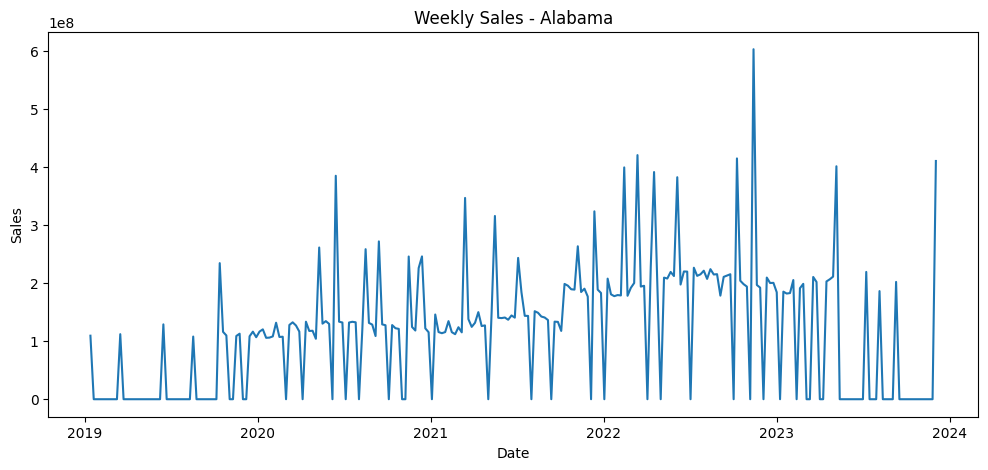

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(weekly_sales)

plt.title("Weekly Sales - Alabama")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

IMPROVE MISSING VALUE HANDLING

In [16]:
weekly_sales = alabama_df["Total"].resample("W").sum()

weekly_sales = weekly_sales.replace(0, pd.NA)

weekly_sales = weekly_sales.ffill()

weekly_sales.head(10)

Date
2019-01-13    109574036
2019-01-20    109574036
2019-01-27    109574036
2019-02-03    109574036
2019-02-10    109574036
2019-02-17    109574036
2019-02-24    109574036
2019-03-03    109574036
2019-03-10    109574036
2019-03-17    112189104
Freq: W-SUN, Name: Total, dtype: object

In [17]:
weekly_sales = pd.to_numeric(weekly_sales)

weekly_sales.dtype

dtype('int64')

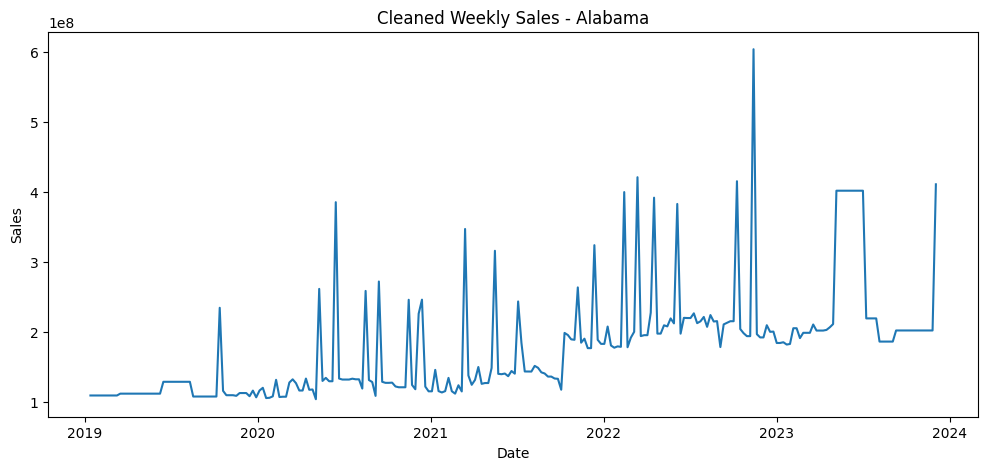

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(weekly_sales)

plt.title("Cleaned Weekly Sales - Alabama")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

LAG FEATURES

In [19]:
feature_df = pd.DataFrame()

feature_df["sales"] = weekly_sales

In [20]:
feature_df["lag_1"] = feature_df["sales"].shift(1)

feature_df["lag_7"] = feature_df["sales"].shift(7)

feature_df["lag_30"] = feature_df["sales"].shift(30)

feature_df.head(35)

,sales,lag_1,lag_7,lag_30
Date,,,,
2019-01-13,109574036,NaN,NaN,NaN
2019-01-20,109574036,109574036.0,NaN,NaN
2019-01-27,109574036,109574036.0,NaN,NaN
2019-02-03,109574036,109574036.0,NaN,NaN
2019-02-10,109574036,109574036.0,NaN,NaN
2019-02-17,109574036,109574036.0,NaN,NaN
2019-02-24,109574036,109574036.0,NaN,NaN
2019-03-03,109574036,109574036.0,109574036.0,NaN
2019-03-10,109574036,109574036.0,109574036.0,NaN


CREATE ROLLING FEATURES

In [21]:
feature_df["rolling_mean_4"] = feature_df["sales"].rolling(window=4).mean()

feature_df["rolling_std_4"] = feature_df["sales"].rolling(window=4).std()

feature_df.head(10)

,sales,lag_1,lag_7,lag_30,rolling_mean_4,rolling_std_4
Date,,,,,,
2019-01-13,109574036,NaN,NaN,NaN,NaN,NaN
2019-01-20,109574036,109574036.0,NaN,NaN,NaN,NaN
2019-01-27,109574036,109574036.0,NaN,NaN,NaN,NaN
2019-02-03,109574036,109574036.0,NaN,NaN,109574036.0,0.0
2019-02-10,109574036,109574036.0,NaN,NaN,109574036.0,0.0
2019-02-17,109574036,109574036.0,NaN,NaN,109574036.0,0.0
2019-02-24,109574036,109574036.0,NaN,NaN,109574036.0,0.0
2019-03-03,109574036,109574036.0,109574036.0,NaN,109574036.0,0.0
2019-03-10,109574036,109574036.0,109574036.0,NaN,109574036.0,0.0


DATE FEATURES

In [22]:
feature_df["month"] = feature_df.index.month

feature_df["quarter"] = feature_df.index.quarter

feature_df["week_of_year"] = feature_df.index.isocalendar().week

feature_df.head()

,sales,lag_1,lag_7,lag_30,rolling_mean_4,rolling_std_4,month,quarter,week_of_year
Date,,,,,,,,,
2019-01-13,109574036,NaN,NaN,NaN,NaN,NaN,1,1,2
2019-01-20,109574036,109574036.0,NaN,NaN,NaN,NaN,1,1,3
2019-01-27,109574036,109574036.0,NaN,NaN,NaN,NaN,1,1,4
2019-02-03,109574036,109574036.0,NaN,NaN,109574036.0,0.0,2,1,5
2019-02-10,109574036,109574036.0,NaN,NaN,109574036.0,0.0,2,1,6


REMOVE NaN ROWS

In [24]:
feature_df = feature_df.dropna()

feature_df.head()

,sales,lag_1,lag_7,lag_30,rolling_mean_4,rolling_std_4,month,quarter,week_of_year
Date,,,,,,,,,
2019-08-11,129106730,129106730.0,129106730.0,109574036.0,129106730.0,0.000000e+00,8,3,32
2019-08-18,108083724,129106730.0,129106730.0,109574036.0,123850978.5,1.051150e+07,8,3,33
2019-08-25,108083724,108083724.0,129106730.0,109574036.0,118595227.0,1.213764e+07,8,3,34
2019-09-01,108083724,108083724.0,129106730.0,109574036.0,113339475.5,1.051150e+07,9,3,35
2019-09-08,108083724,108083724.0,129106730.0,109574036.0,108083724.0,0.000000e+00,9,3,36


CREATE FEATURES & TARGET

In [25]:
X = feature_df.drop("sales", axis=1)

y = feature_df["sales"]

TIME SERIES TRAIN-TEST SPLIT

In [29]:
split_index = int(len(feature_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (180, 8)
X_test shape: (46, 8)


TRAIN XGBOOST MODEL

In [30]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

MAKE PREDICTIONS

In [31]:
y_pred = xgb_model.predict(X_test)

y_pred[:5]

array([1.8147659e+08, 1.8125314e+08, 1.8271717e+08, 1.9179674e+08,
       2.2539885e+08], dtype=float32)

CALCULATE METRICS

In [32]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

rmse = root_mean_squared_error(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 25629952.0
RMSE: 52034196.0


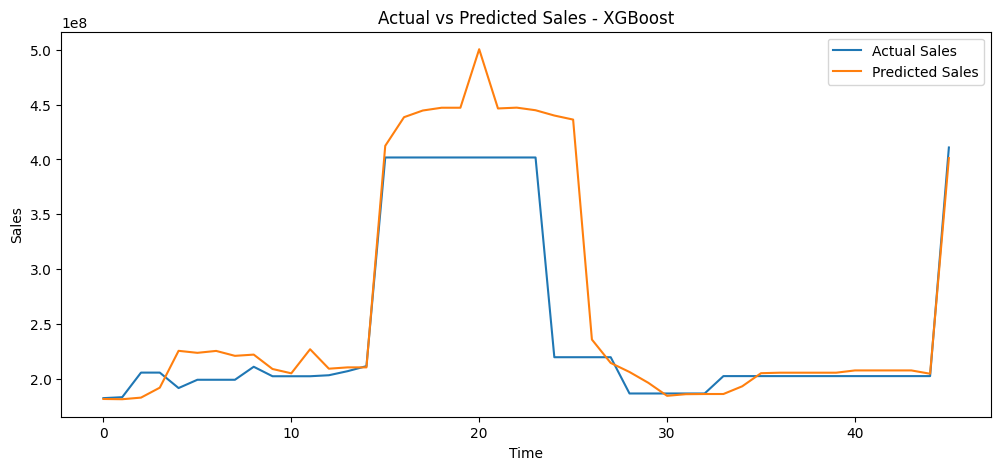

In [33]:
plt.figure(figsize=(12, 5))

plt.plot(y_test.values, label="Actual Sales")

plt.plot(y_pred, label="Predicted Sales")

plt.title("Actual vs Predicted Sales - XGBoost")

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()

CREATE PROPHET DATAFRAME

In [34]:
prophet_df = weekly_sales.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2019-01-13,109574036
1,2019-01-20,109574036
2,2019-01-27,109574036
3,2019-02-03,109574036
4,2019-02-10,109574036


TRAIN PROPHET MODEL

In [35]:
from prophet import Prophet

prophet_model = Prophet()

prophet_model.fit(prophet_df)

Importing plotly failed. Interactive plots will not work.
19:30:59 - cmdstanpy - INFO - Chain [1] start processing
19:31:04 - cmdstanpy - INFO - Chain [1] done processing


In [36]:
future = prophet_model.make_future_dataframe(periods=8, freq="W")

future.tail(10)

,ds
254,2023-11-26
255,2023-12-03
256,2023-12-10
257,2023-12-17
258,2023-12-24
259,2023-12-31
260,2024-01-07
261,2024-01-14
262,2024-01-21
263,2024-01-28


In [37]:
forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(10)

,ds,yhat,yhat_lower,yhat_upper
254,2023-11-26,2.698179e+08,1.903678e+08,3.426850e+08
255,2023-12-03,2.665398e+08,1.949614e+08,3.432159e+08
256,2023-12-10,2.685439e+08,1.975466e+08,3.434971e+08
257,2023-12-17,2.704604e+08,1.924404e+08,3.428342e+08
258,2023-12-24,2.632987e+08,1.858075e+08,3.410701e+08
259,2023-12-31,2.470668e+08,1.731423e+08,3.186502e+08
260,2024-01-07,2.333634e+08,1.556017e+08,3.076729e+08
261,2024-01-14,2.336969e+08,1.635693e+08,3.071254e+08
262,2024-01-21,2.467212e+08,1.760133e+08,3.243825e+08
263,2024-01-28,2.594725e+08,1.817809e+08,3.336908e+08


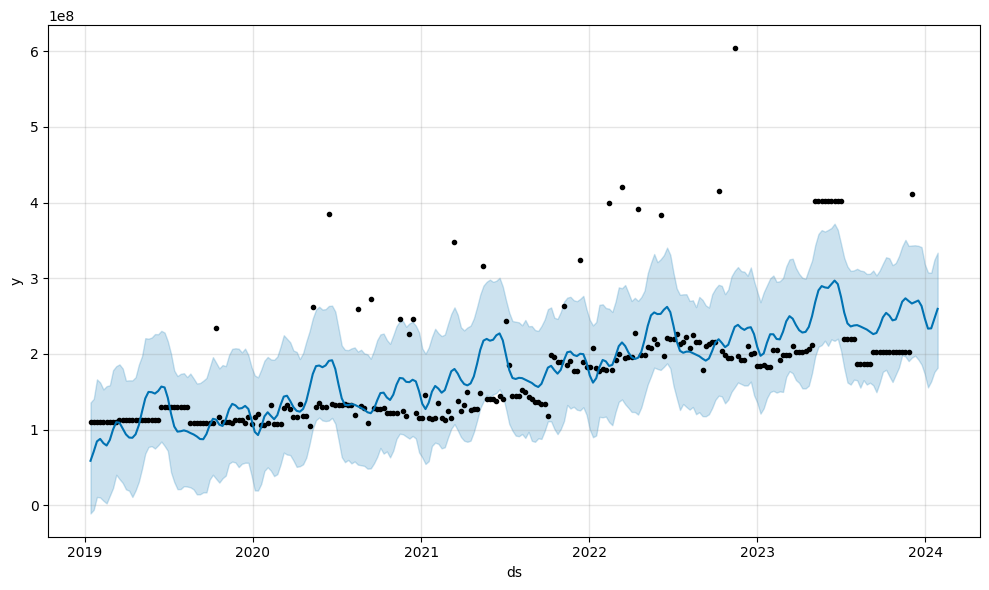

In [38]:
fig = prophet_model.plot(forecast)

In [54]:
prophet_test = forecast.iloc[-len(test):]

prophet_pred = prophet_test["yhat"].values

prophet_actual = test.values

In [55]:
prophet_mae = mean_absolute_error(prophet_actual, prophet_pred)

prophet_rmse = root_mean_squared_error(prophet_actual, prophet_pred)

print("Prophet MAE:", prophet_mae)
print("Prophet RMSE:", prophet_rmse)

Prophet MAE: 72660528.31804615
Prophet RMSE: 86687332.89461012


TRAIN-TEST SPLIT FOR ARIMA

In [39]:
train_size = int(len(weekly_sales) * 0.8)

train = weekly_sales[:train_size]

test = weekly_sales[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))

Train size: 204
Test size: 52


TRAIN BASIC ARIMA MODEL

In [40]:
from statsmodels.tsa.arima.model import ARIMA

arima_model = ARIMA(train, order=(1,1,1))

arima_result = arima_model.fit()

print(arima_result.summary())

                               SARIMAX Results                                
Dep. Variable:                  Total   No. Observations:                  204
Model:                 ARIMA(1, 1, 1)   Log Likelihood               -3918.148
Date:                Wed, 06 May 2026   AIC                           7842.296
Time:                        19:50:40   BIC                           7852.236
Sample:                    01-13-2019   HQIC                          7846.318
                         - 12-04-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0763      0.157     -0.487      0.626      -0.383       0.231
ma.L1         -0.9048      0.042    -21.671      0.000      -0.987      -0.823
sigma2      3.944e+15   2.79e-18   1.41e+33      0.0

In [42]:
arima_pred = arima_result.forecast(steps=len(test))

arima_pred[:5]

2022-12-11    2.467385e+08
2022-12-18    2.425961e+08
2022-12-25    2.429120e+08
2023-01-01    2.428879e+08
2023-01-08    2.428898e+08
Freq: W-SUN, Name: predicted_mean, dtype: float64

In [43]:
arima_mae = mean_absolute_error(test, arima_pred)

arima_rmse = root_mean_squared_error(test, arima_pred)

print("ARIMA MAE:", arima_mae)
print("ARIMA RMSE:", arima_rmse)

ARIMA MAE: 65283749.11647479
ARIMA RMSE: 80456761.02435549


VISUALIZE ARIMA PREDICTIONS

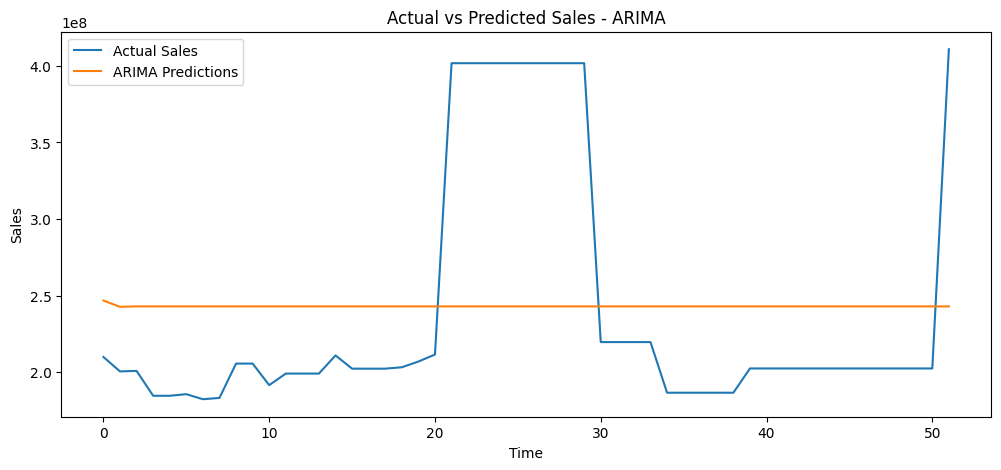

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(test.values, label="Actual Sales")

plt.plot(arima_pred.values, label="ARIMA Predictions")

plt.title("Actual vs Predicted Sales - ARIMA")

plt.xlabel("Time")
plt.ylabel("Sales")

plt.legend()

plt.show()

NOW FINAL MANDATORY MODEL
LSTM

SCALE DATA


In [45]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

scaled_sales = scaler.fit_transform(weekly_sales.values.reshape(-1, 1))

scaled_sales[:5]

array([[0.01068029],
       [0.01068029],
       [0.01068029],
       [0.01068029],
       [0.01068029]])

In [47]:
import numpy as np
sequence_length = 4

X_lstm = []
y_lstm = []

for i in range(sequence_length, len(scaled_sales)):
    X_lstm.append(scaled_sales[i-sequence_length:i])
    y_lstm.append(scaled_sales[i])

X_lstm = np.array(X_lstm)
y_lstm = np.array(y_lstm)

print(X_lstm.shape)
print(y_lstm.shape)

(252, 4, 1)
(252, 1)


TRAIN-TEST SPLIT

In [48]:
split_index = int(len(X_lstm) * 0.8)

X_train_lstm = X_lstm[:split_index]
X_test_lstm = X_lstm[split_index:]

y_train_lstm = y_lstm[:split_index]
y_test_lstm = y_lstm[split_index:]

print(X_train_lstm.shape)
print(X_test_lstm.shape)

(201, 4, 1)
(51, 4, 1)


BUILD LSTM NETWORK

In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(LSTM(50, activation="relu", input_shape=(4, 1)))

lstm_model.add(Dense(1))

lstm_model.compile(optimizer="adam", loss="mse")

lstm_model.summary()


c:\Users\LENOVO\projects\forecasting-system\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN LSTM MODEL

In [50]:
history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=20,
    batch_size=8,
    validation_data=(X_test_lstm, y_test_lstm)
)

Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0254 - val_loss: 0.0494
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0179 - val_loss: 0.0302
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0174 - val_loss: 0.0278
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0168 - val_loss: 0.0289
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0163 - val_loss: 0.0238
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0157 - val_loss: 0.0210
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0155 - val_loss: 0.0191
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0154 - val_loss: 0.0224
Epoch 9/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0151 - val_loss: 0.0173
Epoch 10/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0148 - val_loss: 0.0177
Epoch 11/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0146 - val_loss: 0.0169
Epoch 12/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.014

In [51]:
lstm_pred = lstm_model.predict(X_test_lstm)

lstm_pred[:5]

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step


array([[0.22634766],
       [0.22675662],
       [0.22884339],
       [0.22814454],
       [0.21953546]], dtype=float32)

INVERSE TRANSFORM

In [52]:
lstm_pred_actual = scaler.inverse_transform(lstm_pred)

y_test_actual = scaler.inverse_transform(y_test_lstm)

lstm_pred_actual[:5]

array([[2.1728531e+08],
       [2.1748955e+08],
       [2.1853176e+08],
       [2.1818274e+08],
       [2.1388307e+08]], dtype=float32)

In [53]:
lstm_mae = mean_absolute_error(y_test_actual, lstm_pred_actual)

lstm_rmse = root_mean_squared_error(y_test_actual, lstm_pred_actual)

print("LSTM MAE:", lstm_mae)
print("LSTM RMSE:", lstm_rmse)

LSTM MAE: 46433363.196078435
LSTM RMSE: 72624389.43786834


SAVE MODEL XGBOOST

In [56]:
import joblib

joblib.dump(xgb_model, "../models/xgboost_model.pkl")

print("XGBoost model saved successfully!")

XGBoost model saved successfully!


In [57]:
joblib.dump(scaler, "../models/scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
